In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/dataset.csv")

print(df.head(10))

           x_Timestamp  t_kWh  z_Avg Voltage (Volt)  z_Avg Current (Amp)  \
0  2021-01-02 00:00:00  0.002                253.36                 0.25   
1  2021-01-02 00:03:00  0.002                253.87                 0.25   
2  2021-01-02 00:06:00  0.020                253.25                 1.67   
3  2021-01-02 00:09:00  0.045                252.20                 3.52   
4  2021-01-02 00:12:00  0.044                252.28                 3.53   
5  2021-01-02 00:15:00  0.042                252.51                 3.15   
6  2021-01-02 00:18:00  0.001                253.97                 0.14   
7  2021-01-02 00:21:00  0.001                253.93                 0.14   
8  2021-01-02 00:24:00  0.001                253.79                 0.14   
9  2021-01-02 00:27:00  0.001                253.81                 0.14   

   y_Freq (Hz) meter  
0        50.09  BR02  
1        50.11  BR02  
2        50.14  BR02  
3        50.12  BR02  
4        50.07  BR02  
5        50.10  BR02  
6 

In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (3948960, 6)

Column names:
['x_Timestamp', 't_kWh', 'z_Avg Voltage (Volt)', 'z_Avg Current (Amp)', 'y_Freq (Hz)', 'meter']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 3948960 entries, 0 to 3948959
Data columns (total 6 columns):
 #   Column                Dtype  
---  ------                -----  
 0   x_Timestamp           str    
 1   t_kWh                 float64
 2   z_Avg Voltage (Volt)  float64
 3   z_Avg Current (Amp)   float64
 4   y_Freq (Hz)           float64
 5   meter                 str    
dtypes: float64(4), str(2)
memory usage: 267.4 MB


In [5]:
print(df.isnull().sum())

x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64


In [6]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)


Python executable:
c:\Users\Raghav Tripathi\OneDrive\Documents\WattNext\.venv\Scripts\python.exe

Python version:
3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]


In [7]:
# ==========================================
# WATTNEXT - DATASET OVERVIEW
# ==========================================

import pandas as pd

# Display basic information
print("Dataset shape:", df.shape)

print("\nColumn names:")
for column in df.columns:
    print("-", column)

print("\nData types:")
print(df.dtypes)

print("\nMemory usage:")
print(f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Dataset shape: (3948960, 6)

Column names:
- x_Timestamp
- t_kWh
- z_Avg Voltage (Volt)
- z_Avg Current (Amp)
- y_Freq (Hz)
- meter

Data types:
x_Timestamp                 str
t_kWh                   float64
z_Avg Voltage (Volt)    float64
z_Avg Current (Amp)     float64
y_Freq (Hz)             float64
meter                       str
dtype: object

Memory usage:
267.39 MB


In [8]:
# ==========================================
# TIMESTAMP AND METER INSPECTION
# ==========================================

# Convert timestamp safely
df["x_Timestamp"] = pd.to_datetime(
    df["x_Timestamp"],
    errors="coerce"
)

print("Earliest timestamp:", df["x_Timestamp"].min())
print("Latest timestamp:", df["x_Timestamp"].max())

print("\nInvalid timestamps:", df["x_Timestamp"].isna().sum())

print("\nUnique meters:", df["meter"].nunique())

print("\nReadings per meter:")
print(df["meter"].value_counts().describe())

Earliest timestamp: 2021-01-01 00:00:00
Latest timestamp: 2021-10-31 23:57:00

Invalid timestamps: 0

Unique meters: 38

Readings per meter:
count        38.000000
mean     103920.000000
std       51471.694662
min         480.000000
25%       60120.000000
50%      135600.000000
75%      143400.000000
max      145440.000000
Name: count, dtype: float64


In [9]:
# ==========================================
# DATA QUALITY CHECK
# ==========================================

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNegative energy readings:")
print((df["t_kWh"] < 0).sum())

print("\nNegative voltage readings:")
print((df["z_Avg Voltage (Volt)"] < 0).sum())

print("\nNegative current readings:")
print((df["z_Avg Current (Amp)"] < 0).sum())

print("\nFrequency summary:")
print(df["y_Freq (Hz)"].describe())

Missing values:
x_Timestamp             0
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
meter                   0
dtype: int64

Duplicate rows: 0

Negative energy readings:
0

Negative voltage readings:
0

Negative current readings:
0

Frequency summary:
count    3.948960e+06
mean     4.564049e+01
std      1.410652e+01
min      0.000000e+00
25%      4.995000e+01
50%      5.000000e+01
75%      5.004000e+01
max      1.773000e+02
Name: y_Freq (Hz), dtype: float64


In [10]:
# ==========================================
# WATTNEXT - METER COVERAGE ANALYSIS
# ==========================================

# Ensure timestamps are datetime
df["x_Timestamp"] = pd.to_datetime(
    df["x_Timestamp"],
    errors="coerce"
)

# Group data by meter
meter_summary = df.groupby("meter").agg(
    first_reading=("x_Timestamp", "min"),
    last_reading=("x_Timestamp", "max"),
    total_readings=("x_Timestamp", "count"),
    average_energy=("t_kWh", "mean"),
    maximum_energy=("t_kWh", "max")
).sort_values("total_readings")

print(meter_summary)

      first_reading        last_reading  total_readings  average_energy  \
meter                                                                     
BR42     2021-01-12 2021-01-12 23:57:00             480        0.000000   
BR46     2021-01-02 2021-03-05 23:57:00           10080        0.000583   
BR52     2021-01-01 2021-03-03 23:57:00           15360        0.001919   
BR02     2021-01-02 2021-03-07 23:57:00           18720        0.004643   
BR08     2021-01-01 2021-02-16 23:57:00           21120        0.005694   
BR38     2021-01-04 2021-03-04 23:57:00           27360        0.006748   
BR18     2021-01-01 2021-03-07 23:57:00           27840        0.015207   
BR09     2021-01-01 2021-03-07 23:57:00           31200        0.006049   
BR12     2021-01-01 2021-03-07 23:57:00           31680        0.021158   
BR05     2021-01-01 2021-08-05 23:57:00           49920        0.005422   
BR43     2021-01-01 2021-10-31 23:57:00           90720        0.003767   
BR50     2021-01-01 2021-

In [11]:
# Display meter coverage in a readable format

print("Number of meters:", len(meter_summary))

print("\nMeters with the fewest readings:")
print(meter_summary.head(10))

print("\nMeters with the most readings:")
print(meter_summary.tail(10))

Number of meters: 38

Meters with the fewest readings:
      first_reading        last_reading  total_readings  average_energy  \
meter                                                                     
BR42     2021-01-12 2021-01-12 23:57:00             480        0.000000   
BR46     2021-01-02 2021-03-05 23:57:00           10080        0.000583   
BR52     2021-01-01 2021-03-03 23:57:00           15360        0.001919   
BR02     2021-01-02 2021-03-07 23:57:00           18720        0.004643   
BR08     2021-01-01 2021-02-16 23:57:00           21120        0.005694   
BR38     2021-01-04 2021-03-04 23:57:00           27360        0.006748   
BR18     2021-01-01 2021-03-07 23:57:00           27840        0.015207   
BR09     2021-01-01 2021-03-07 23:57:00           31200        0.006049   
BR12     2021-01-01 2021-03-07 23:57:00           31680        0.021158   
BR05     2021-01-01 2021-08-05 23:57:00           49920        0.005422   

       maximum_energy  
meter               

In [12]:
# ==========================================
# WATTNEXT - TIME COVERAGE ANALYSIS
# ==========================================

# Sort the data
df_sorted = df.sort_values(
    ["meter", "x_Timestamp"]
).copy()

# Calculate time difference between consecutive readings
df_sorted["time_difference"] = (
    df_sorted
    .groupby("meter")["x_Timestamp"]
    .diff()
)

# Display time gap distribution
print("Time difference distribution:")
print(df_sorted["time_difference"].value_counts().head(15))

print("\nLargest time gaps:")
print(
    df_sorted
    .groupby("meter")["time_difference"]
    .max()
    .sort_values(ascending=False)
)

Time difference distribution:
time_difference
0 days 00:03:00     3948566
1 days 00:03:00         275
2 days 00:03:00          47
3 days 00:03:00          12
10 days 00:03:00          3
6 days 00:03:00           3
4 days 00:03:00           3
5 days 00:03:00           3
19 days 00:03:00          2
7 days 00:03:00           2
16 days 00:03:00          1
13 days 00:03:00          1
73 days 00:03:00          1
15 days 00:03:00          1
93 days 00:03:00          1
Name: count, dtype: int64

Largest time gaps:
meter
BR43   93 days 00:03:00
BR05   73 days 00:03:00
BR04   19 days 00:03:00
BR16   19 days 00:03:00
BR46   14 days 00:03:00
BR02   10 days 00:03:00
BR34   10 days 00:03:00
BR18    7 days 00:03:00
BR39    6 days 00:03:00
BR35    5 days 00:03:00
BR33    5 days 00:03:00
BR32    5 days 00:03:00
BR52    4 days 00:03:00
BR49    3 days 00:03:00
BR48    3 days 00:03:00
BR13    3 days 00:03:00
BR51    2 days 00:03:00
BR50    2 days 00:03:00
BR36    2 days 00:03:00
BR22    1 days 00:03:00
BR

In [13]:
# ==========================================
# WATTNEXT - METER DATA QUALITY REPORT
# ==========================================

# Expected interval between readings
EXPECTED_INTERVAL = pd.Timedelta(minutes=3)

# Calculate statistics for each meter
coverage_report = df_sorted.groupby("meter").agg(
    first_reading=("x_Timestamp", "min"),
    last_reading=("x_Timestamp", "max"),
    total_readings=("x_Timestamp", "count"),
    largest_gap=("time_difference", "max")
)

# Count gaps larger than the expected 3-minute interval
large_gaps = (
    df_sorted["time_difference"] > EXPECTED_INTERVAL
)

gap_counts = (
    df_sorted[large_gaps]
    .groupby("meter")
    .size()
    .rename("large_gap_count")
)

# Add gap counts to the report
coverage_report = coverage_report.join(
    gap_counts,
    how="left"
)

coverage_report["large_gap_count"] = (
    coverage_report["large_gap_count"]
    .fillna(0)
    .astype(int)
)

# Calculate the observed time span
coverage_report["observed_days"] = (
    coverage_report["last_reading"]
    - coverage_report["first_reading"]
).dt.total_seconds() / (24 * 60 * 60)

# Display the report
coverage_report = coverage_report.sort_values(
    "total_readings"
)

print(coverage_report.to_string())

      first_reading        last_reading  total_readings      largest_gap  large_gap_count  observed_days
meter                                                                                                   
BR42     2021-01-12 2021-01-12 23:57:00             480  0 days 00:03:00                0       0.997917
BR46     2021-01-02 2021-03-05 23:57:00           10080 14 days 00:03:00               10      62.997917
BR52     2021-01-01 2021-03-03 23:57:00           15360  4 days 00:03:00               18      61.997917
BR02     2021-01-02 2021-03-07 23:57:00           18720 10 days 00:03:00                9      64.997917
BR08     2021-01-01 2021-02-16 23:57:00           21120  1 days 00:03:00                3      46.997917
BR38     2021-01-04 2021-03-04 23:57:00           27360  1 days 00:03:00                3      59.997917
BR18     2021-01-01 2021-03-07 23:57:00           27840  7 days 00:03:00                2      65.997917
BR09     2021-01-01 2021-03-07 23:57:00           31200

In [14]:
# ==========================================
# WATTNEXT - METER COMPLETENESS ANALYSIS
# ==========================================

# Expected number of readings per day
READINGS_PER_DAY = 24 * 60 // 3

# Calculate expected readings based on each meter's observed period
coverage_report["expected_readings"] = (
    (coverage_report["observed_days"] + 1 / 1440)
    * READINGS_PER_DAY
).round().astype(int)

# Calculate basic observed completeness
coverage_report["completeness_percentage"] = (
    coverage_report["total_readings"]
    / coverage_report["expected_readings"]
    * 100
).clip(upper=100)

# Display selected columns
completeness_view = coverage_report[
    [
        "first_reading",
        "last_reading",
        "total_readings",
        "expected_readings",
        "completeness_percentage",
        "large_gap_count"
    ]
].sort_values("completeness_percentage")

print(completeness_view.to_string())

      first_reading        last_reading  total_readings  expected_readings  completeness_percentage  large_gap_count
meter                                                                                                               
BR46     2021-01-02 2021-03-05 23:57:00           10080              30239                33.334436               10
BR05     2021-01-01 2021-08-05 23:57:00           49920             104159                47.926727               21
BR52     2021-01-01 2021-03-03 23:57:00           15360              29759                51.614638               18
BR02     2021-01-02 2021-03-07 23:57:00           18720              31199                60.001923                9
BR43     2021-01-01 2021-10-31 23:57:00           90720             145919                62.171479               19
BR13     2021-01-01 2021-10-31 23:57:00          111360             145919                76.316312               58
BR16     2021-01-02 2021-09-28 23:57:00          101760         

Matplotlib is building the font cache; this may take a moment.


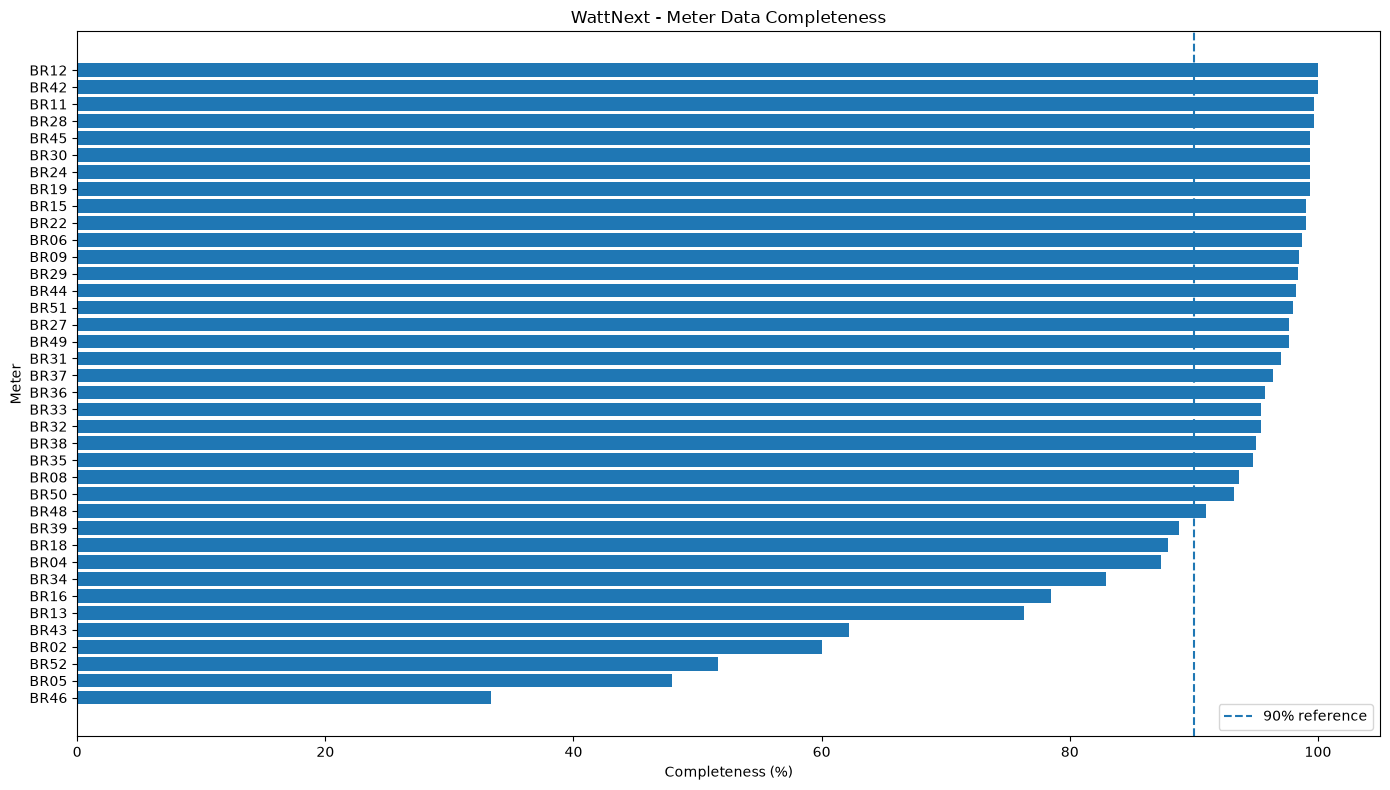

In [15]:
# ==========================================
# WATTNEXT - COMPLETENESS VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# Sort meters by completeness
plot_data = coverage_report.sort_values(
    "completeness_percentage"
)

# Create the chart
plt.figure(figsize=(14, 8))

plt.barh(
    plot_data.index,
    plot_data["completeness_percentage"]
)

plt.xlabel("Completeness (%)")
plt.ylabel("Meter")
plt.title("WattNext - Meter Data Completeness")

# Add a reference line at 90%
plt.axvline(
    x=90,
    linestyle="--",
    label="90% reference"
)

plt.xlim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# WATTNEXT - ABNORMAL VALUE ANALYSIS
# ==========================================

numeric_columns = [
    "t_kWh",
    "z_Avg Voltage (Volt)",
    "z_Avg Current (Amp)",
    "y_Freq (Hz)"
]

# Display statistical summary
print("STATISTICAL SUMMARY")
print("=" * 60)

print(df[numeric_columns].describe().T)

# Check for zero values
print("\nZERO VALUE COUNTS")
print("=" * 60)

for column in numeric_columns:
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")

# Check for negative values
print("\nNEGATIVE VALUE COUNTS")
print("=" * 60)

for column in numeric_columns:
    negative_count = (df[column] < 0).sum()
    print(f"{column}: {negative_count}")

# Check for missing values
print("\nMISSING VALUE COUNTS")
print("=" * 60)

print(df[numeric_columns].isnull().sum())

STATISTICAL SUMMARY
                          count        mean        std  min      25%      50%  \
t_kWh                 3948960.0    0.019406   0.027463  0.0    0.003    0.011   
z_Avg Voltage (Volt)  3948960.0  219.557971  70.039794  0.0  225.920  239.990   
z_Avg Current (Amp)   3948960.0    1.805567   2.378093  0.0    0.360    1.060   
y_Freq (Hz)           3948960.0   45.640489  14.106524  0.0   49.950   50.000   

                          75%     max  
t_kWh                   0.023    0.30  
z_Avg Voltage (Volt)  251.090  654.50  
z_Avg Current (Amp)     2.250   30.59  
y_Freq (Hz)            50.040  177.30  

ZERO VALUE COUNTS
t_kWh: 602519
z_Avg Voltage (Volt): 344294
z_Avg Current (Amp): 499929
y_Freq (Hz): 344295

NEGATIVE VALUE COUNTS
t_kWh: 0
z_Avg Voltage (Volt): 0
z_Avg Current (Amp): 0
y_Freq (Hz): 0

MISSING VALUE COUNTS
t_kWh                   0
z_Avg Voltage (Volt)    0
z_Avg Current (Amp)     0
y_Freq (Hz)             0
dtype: int64


In [18]:
# ==========================================
# WATTNEXT - ZERO VALUE PERCENTAGES
# ==========================================

print("ZERO VALUE ANALYSIS")
print("=" * 60)

for column in numeric_columns:
    zero_count = (df[column] == 0).sum()
    zero_percentage = (zero_count / len(df)) * 100

    print(f"\nColumn: {column}")
    print(f"Zero readings: {zero_count:,}")
    print(f"Zero percentage: {zero_percentage:.2f}%")

ZERO VALUE ANALYSIS

Column: t_kWh
Zero readings: 602,519
Zero percentage: 15.26%

Column: z_Avg Voltage (Volt)
Zero readings: 344,294
Zero percentage: 8.72%

Column: z_Avg Current (Amp)
Zero readings: 499,929
Zero percentage: 12.66%

Column: y_Freq (Hz)
Zero readings: 344,295
Zero percentage: 8.72%


In [19]:
# ==========================================
# WATTNEXT - COMBINED ZERO VALUE ANALYSIS
# ==========================================

zero_columns = [
    "t_kWh",
    "z_Avg Voltage (Volt)",
    "z_Avg Current (Amp)",
    "y_Freq (Hz)"
]

# Count rows where all four measurements are zero
all_zero_mask = (df[zero_columns] == 0).all(axis=1)

print("Rows where all measurements are zero:")
print(all_zero_mask.sum())

print(
    "Percentage of rows where all measurements are zero:",
    f"{all_zero_mask.mean() * 100:.2f}%"
)

# Count rows where at least one measurement is zero
any_zero_mask = (df[zero_columns] == 0).any(axis=1)

print("\nRows where at least one measurement is zero:")
print(any_zero_mask.sum())

print(
    "Percentage of rows where at least one measurement is zero:",
    f"{any_zero_mask.mean() * 100:.2f}%"
)

Rows where all measurements are zero:
343469
Percentage of rows where all measurements are zero: 8.70%

Rows where at least one measurement is zero:
603645
Percentage of rows where at least one measurement is zero: 15.29%


In [20]:
# ==========================================
# WATTNEXT - ZERO READINGS BY METER
# ==========================================

zero_analysis = df.groupby("meter").agg(
    total_readings=("meter", "size"),
    zero_energy=("t_kWh", lambda x: (x == 0).sum()),
    all_measurements_zero=(
        "t_kWh",
        lambda x: 0  # Placeholder
    )
)

# Calculate rows where all measurements are zero
df["all_measurements_zero"] = (
    df[zero_columns] == 0
).all(axis=1)

zero_analysis = df.groupby("meter").agg(
    total_readings=("meter", "size"),
    zero_energy=("t_kWh", lambda x: (x == 0).sum()),
    all_zero_rows=("all_measurements_zero", "sum")
)

zero_analysis["zero_energy_percentage"] = (
    zero_analysis["zero_energy"]
    / zero_analysis["total_readings"]
    * 100
)

zero_analysis["all_zero_percentage"] = (
    zero_analysis["all_zero_rows"]
    / zero_analysis["total_readings"]
    * 100
)

zero_analysis = zero_analysis.sort_values(
    "all_zero_percentage",
    ascending=False
)

print(zero_analysis.to_string())

       total_readings  zero_energy  all_zero_rows  zero_energy_percentage  all_zero_percentage
meter                                                                                         
BR33           139200        27749          27351               19.934626            19.648707
BR39           129600        29831          25411               23.017747            19.607253
BR32           139200        50117          27184               36.003592            19.528736
BR34           120960        38012          23549               31.425265            19.468419
BR36           139680        27253          26697               19.511025            19.112973
BR35           138240        26523          26307               19.186198            19.029948
BR37           140640        26906          26752               19.131115            19.021615
BR43            90720        30834          15594               33.988095            17.189153
BR38            27360        16537           4368 

In [21]:
# ==========================================
# WATTNEXT - ZERO ENERGY INVESTIGATION
# ==========================================

# Select rows where energy is zero
zero_energy_data = df[df["t_kWh"] == 0]

print("Total zero-energy rows:", len(zero_energy_data))

print("\nVoltage statistics for zero-energy rows:")
print(zero_energy_data["z_Avg Voltage (Volt)"].describe())

print("\nCurrent statistics for zero-energy rows:")
print(zero_energy_data["z_Avg Current (Amp)"].describe())

print("\nFrequency statistics for zero-energy rows:")
print(zero_energy_data["y_Freq (Hz)"].describe())

Total zero-energy rows: 602519

Voltage statistics for zero-energy rows:
count    602519.000000
mean        102.436256
std         118.867372
min           0.000000
25%           0.000000
50%           0.000000
75%         238.410000
max         653.780000
Name: z_Avg Voltage (Volt), dtype: float64

Current statistics for zero-energy rows:
count    602519.000000
mean          0.014265
std           0.121504
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          12.130000
Name: z_Avg Current (Amp), dtype: float64

Frequency statistics for zero-energy rows:
count    602519.000000
mean         21.497887
std          24.754755
min           0.000000
25%           0.000000
50%           0.000000
75%          50.000000
max         114.250000
Name: y_Freq (Hz), dtype: float64


In [22]:
# ==========================================
# WATTNEXT - ZERO ENERGY WITH CURRENT
# ==========================================

condition = (
    (df["t_kWh"] == 0)
    & (df["z_Avg Current (Amp)"] > 0)
)

zero_energy_with_current = df[condition]

print("Zero-energy rows with nonzero current:")
print(len(zero_energy_with_current))

print(
    "Percentage:",
    f"{len(zero_energy_with_current) / len(df) * 100:.2f}%"
)

print("\nSample readings:")
print(
    zero_energy_with_current[
        [
            "x_Timestamp",
            "meter",
            "t_kWh",
            "z_Avg Voltage (Volt)",
            "z_Avg Current (Amp)",
            "y_Freq (Hz)"
        ]
    ].head(10)
)

Zero-energy rows with nonzero current:
103675
Percentage: 2.63%

Sample readings:
            x_Timestamp meter  t_kWh  z_Avg Voltage (Volt)  \
53  2021-01-02 02:39:00  BR02    0.0                255.50   
84  2021-01-02 04:12:00  BR02    0.0                256.16   
210 2021-01-02 10:30:00  BR02    0.0                236.38   
249 2021-01-02 12:27:00  BR02    0.0                242.71   
251 2021-01-02 12:33:00  BR02    0.0                241.99   
253 2021-01-02 12:39:00  BR02    0.0                242.86   
255 2021-01-02 12:45:00  BR02    0.0                243.40   
256 2021-01-02 12:48:00  BR02    0.0                243.74   
258 2021-01-02 12:54:00  BR02    0.0                243.64   
260 2021-01-02 13:00:00  BR02    0.0                244.26   

     z_Avg Current (Amp)  y_Freq (Hz)  
53                  0.12        49.99  
84                  0.13        50.05  
210                 0.13        49.90  
249                 0.16        49.99  
251                 0.14        49.

In [24]:
# ==========================================
# WATTNEXT - ENERGY AND CURRENT RELATIONSHIP
# ==========================================

# Filter rows where energy is zero and current is positive
condition = (
    (df["t_kWh"] == 0)
    & (df["z_Avg Current (Amp)"] > 0)
)

zero_energy_current = df[condition]

print("Current statistics:")
print(
    zero_energy_current["z_Avg Current (Amp)"].describe()
)

print("\nVoltage statistics:")
print(
    zero_energy_current["z_Avg Voltage (Volt)"].describe()
)

print("\nMeters with zero energy and nonzero current:")
print(
    zero_energy_current["meter"].value_counts()
)

Current statistics:
count    103675.000000
mean          0.082903
std           0.283035
min           0.010000
25%           0.030000
50%           0.030000
75%           0.070000
max          12.130000
Name: z_Avg Current (Amp), dtype: float64

Voltage statistics:
count    103675.000000
mean        245.782866
std          19.612053
min           0.000000
25%         237.630000
50%         247.420000
75%         257.230000
max         651.190000
Name: z_Avg Voltage (Volt), dtype: float64

Meters with zero energy and nonzero current:
meter
BR13    20489
BR43    15096
BR16    10804
BR48     9357
BR34     9316
BR52     7816
BR46     6027
BR27     4460
BR39     4394
BR05     3856
BR50     2508
BR31     2057
BR29     1590
BR02      859
BR36      513
BR32      490
BR44      447
BR33      398
BR15      354
BR45      336
BR38      329
BR22      313
BR08      254
BR19      224
BR35      192
BR18      167
BR28      166
BR04      163
BR37      154
BR11      128
BR51      104
BR24       76
BR30  

In [25]:
# ==========================================
# WATTNEXT - ZERO ENERGY CURRENT BY METER
# ==========================================

zero_energy_current = df[
    (df["t_kWh"] == 0)
    & (df["z_Avg Current (Amp)"] > 0)
]

current_issue_report = zero_energy_current.groupby("meter").size().rename(
    "zero_energy_nonzero_current"
).to_frame()

current_issue_report["total_readings"] = (
    df.groupby("meter").size()
)

current_issue_report["percentage"] = (
    current_issue_report["zero_energy_nonzero_current"]
    / current_issue_report["total_readings"]
    * 100
)

current_issue_report = current_issue_report.sort_values(
    "percentage",
    ascending=False
)

print(current_issue_report.to_string())

       zero_energy_nonzero_current  total_readings  percentage
meter                                                         
BR46                          6027           10080   59.791667
BR52                          7816           15360   50.885417
BR13                         20489          111360   18.398886
BR43                         15096           90720   16.640212
BR16                         10804          101760   10.617138
BR48                          9357           96480    9.698383
BR05                          3856           49920    7.724359
BR34                          9316          120960    7.701720
BR02                           859           18720    4.588675
BR39                          4394          129600    3.390432
BR27                          4460          142560    3.128507
BR50                          2508           92640    2.707254
BR31                          2057          141600    1.452684
BR08                           254           21120    1

In [26]:
# ==========================================
# WATTNEXT - BR46 ENERGY DISTRIBUTION
# ==========================================

br46 = df[df["meter"] == "BR46"]

print("BR46 total readings:", len(br46))

print("\nBR46 energy statistics:")
print(br46["t_kWh"].describe())

print("\nBR46 energy value counts:")
print(br46["t_kWh"].value_counts().head(20))

BR46 total readings: 10080

BR46 energy statistics:
count    10080.000000
mean         0.000583
std          0.003653
min          0.000000
25%          0.000000
50%          0.000000
75%          0.001000
max          0.100000
Name: t_kWh, dtype: float64

BR46 energy value counts:
t_kWh
0.000    7444
0.001    2314
0.006      83
0.005      55
0.004      50
0.007      35
0.002      32
0.037      11
0.003       9
0.008       5
0.038       4
0.013       4
0.044       2
0.045       2
0.010       2
0.051       2
0.009       2
0.029       1
0.043       1
0.047       1
Name: count, dtype: int64


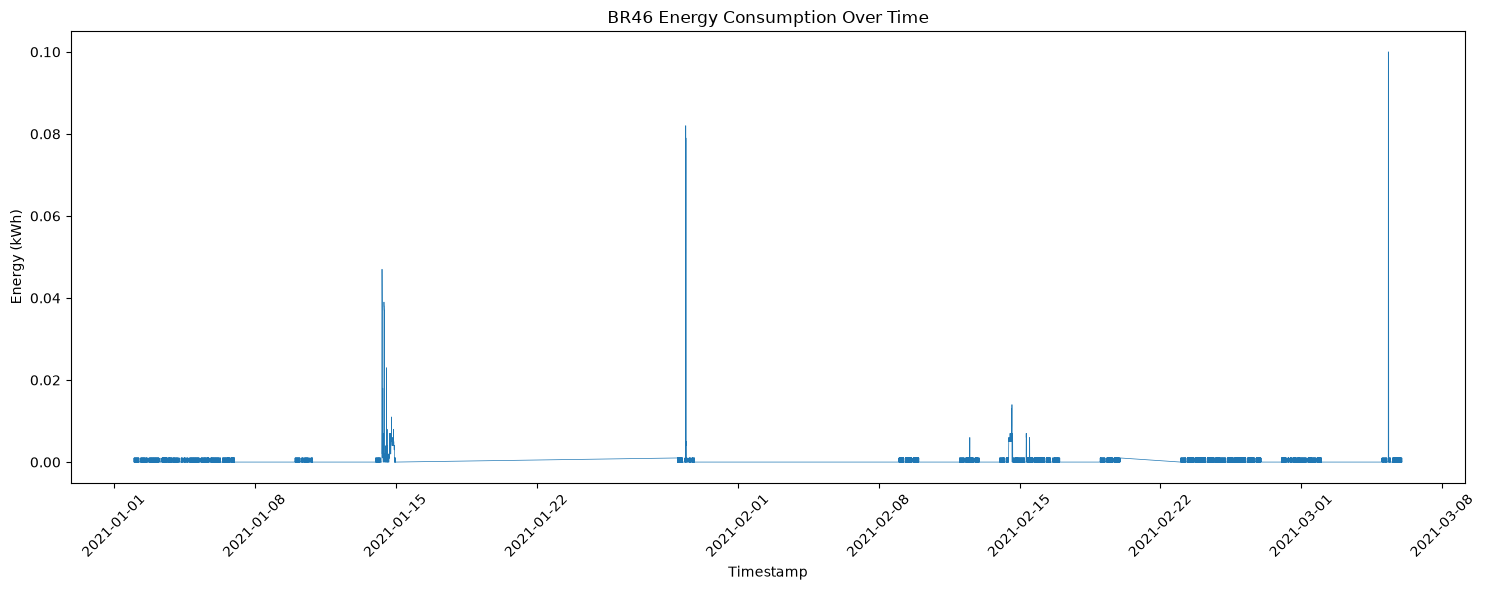

In [27]:
# ==========================================
# WATTNEXT - BR46 ENERGY OVER TIME
# ==========================================

br46 = df[df["meter"] == "BR46"].copy()

br46 = br46.sort_values("x_Timestamp")

plt.figure(figsize=(15, 6))

plt.plot(
    br46["x_Timestamp"],
    br46["t_kWh"],
    linewidth=0.5
)

plt.xlabel("Timestamp")
plt.ylabel("Energy (kWh)")
plt.title("BR46 Energy Consumption Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

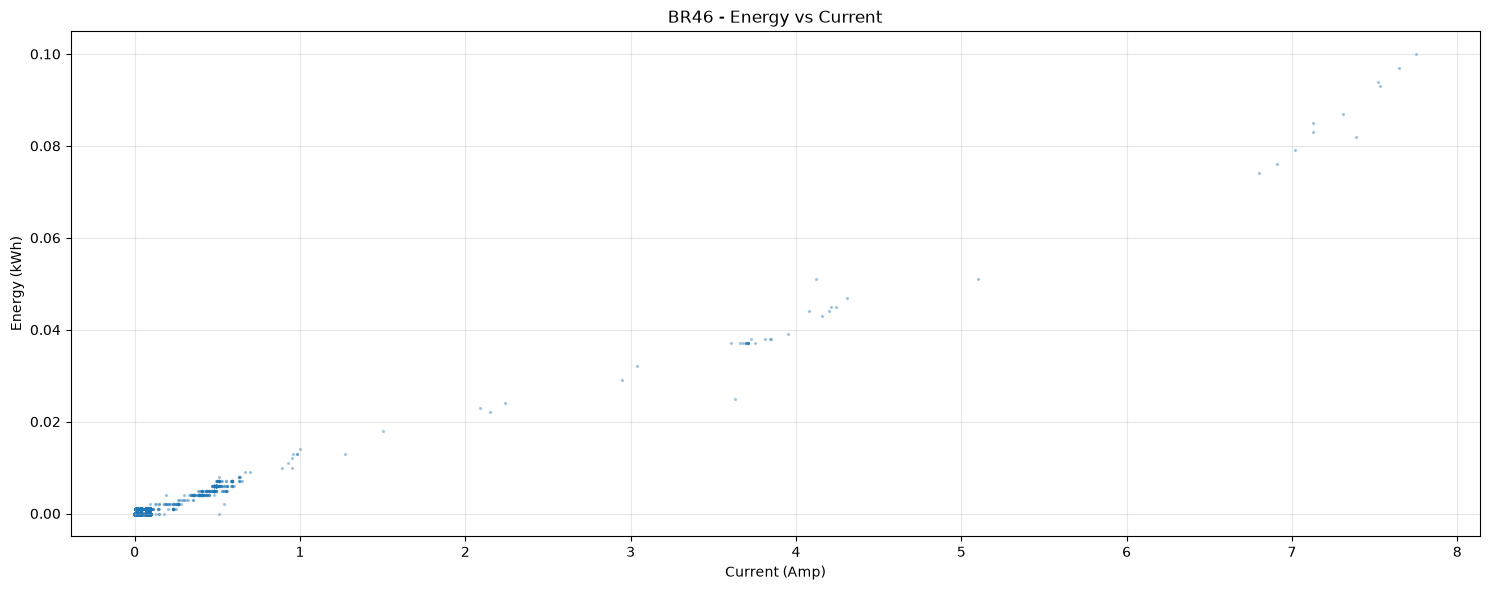

In [28]:
# ==========================================
# WATTNEXT - BR46 ENERGY VS CURRENT
# ==========================================

br46 = df[df["meter"] == "BR46"].copy()

plt.figure(figsize=(15, 6))

plt.scatter(
    br46["z_Avg Current (Amp)"],
    br46["t_kWh"],
    s=2,
    alpha=0.3
)

plt.xlabel("Current (Amp)")
plt.ylabel("Energy (kWh)")
plt.title("BR46 - Energy vs Current")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# WATTNEXT - ENERGY ROUNDING INVESTIGATION
# ==========================================

br46 = df[df["meter"] == "BR46"].copy()

# Estimate apparent energy over 3 minutes.
# This assumes power factor = 1, so it is only a reference estimate.
br46["estimated_energy"] = (
    br46["z_Avg Voltage (Volt)"]
    * br46["z_Avg Current (Amp)"]
    * (3 / 60)
    / 1000
)

# Display low-current readings
low_current = br46[
    (br46["z_Avg Current (Amp)"] > 0)
    & (br46["z_Avg Current (Amp)"] <= 0.10)
]

print("Low-current readings:", len(low_current))

print("\nSample comparison:")
print(
    low_current[
        [
            "z_Avg Voltage (Volt)",
            "z_Avg Current (Amp)",
            "t_kWh",
            "estimated_energy"
        ]
    ].head(20).to_string(index=False)
)


Low-current readings: 8320

Sample comparison:
 z_Avg Voltage (Volt)  z_Avg Current (Amp)  t_kWh  estimated_energy
               268.11                 0.01  0.000          0.000134
               264.49                 0.01  0.001          0.000132
               263.26                 0.01  0.000          0.000132
               263.34                 0.01  0.000          0.000132
               260.55                 0.01  0.000          0.000130
               261.17                 0.01  0.000          0.000131
               261.73                 0.01  0.001          0.000131
               261.52                 0.01  0.000          0.000131
               261.19                 0.01  0.000          0.000131
               259.62                 0.01  0.000          0.000130
               260.70                 0.01  0.000          0.000130
               262.44                 0.01  0.000          0.000131
               263.49                 0.01  0.001          0.000132
 

In [30]:
# ==========================================
# WATTNEXT - EXTREME VALUE CHECK
# ==========================================

# Define suspicious-value conditions
voltage_suspicious = (
    (df["z_Avg Voltage (Volt)"] <= 0)
    | (df["z_Avg Voltage (Volt)"] > 300)
)

frequency_suspicious = (
    (df["y_Freq (Hz)"] <= 0)
    | (df["y_Freq (Hz)"] < 45)
    | (df["y_Freq (Hz)"] > 55)
)

print("SUSPICIOUS VOLTAGE READINGS")
print("=" * 50)
print("Count:", voltage_suspicious.sum())
print("Percentage:", f"{voltage_suspicious.mean() * 100:.2f}%")

print("\nSUSPICIOUS FREQUENCY READINGS")
print("=" * 50)
print("Count:", frequency_suspicious.sum())
print("Percentage:", f"{frequency_suspicious.mean() * 100:.2f}%")

print("\nHighest voltage readings:")
print(df["z_Avg Voltage (Volt)"].nlargest(10).to_list())

print("\nHighest frequency readings:")
print(df["y_Freq (Hz)"].nlargest(10).to_list())

SUSPICIOUS VOLTAGE READINGS
Count: 349793
Percentage: 8.86%

SUSPICIOUS FREQUENCY READINGS
Count: 344622
Percentage: 8.73%

Highest voltage readings:
[654.5, 653.78, 652.93, 651.38, 651.28, 651.19, 651.19, 651.19, 651.19, 651.19]

Highest frequency readings:
[177.3, 118.59, 116.6, 114.25, 101.69, 100.73, 91.1, 90.78, 86.17, 85.56]


In [31]:
# ==========================================
# WATTNEXT - ENERGY CONSUMPTION BY METER
# ==========================================

meter_energy_summary = df.groupby("meter").agg(
    total_energy=("t_kWh", "sum"),
    average_energy=("t_kWh", "mean"),
    total_readings=("t_kWh", "count")
)

meter_energy_summary = meter_energy_summary.sort_values(
    "total_energy",
    ascending=False
)

print(meter_energy_summary.to_string())

       total_energy  average_energy  total_readings
meter                                              
BR51       7084.570        0.049529          143040
BR06       5351.127        0.037161          144000
BR49       5273.997        0.036995          142560
BR24       5187.700        0.035787          144960
BR35       4860.550        0.035160          138240
BR45       4769.515        0.032902          144960
BR19       4579.692        0.031803          144000
BR36       4423.391        0.031668          139680
BR31       3562.241        0.025157          141600
BR22       3420.477        0.023674          144480
BR15       2821.378        0.019528          144480
BR04       2778.372        0.022093          125760
BR29       2578.050        0.017963          143520
BR37       2444.087        0.017378          140640
BR30       2340.608        0.016147          144960
BR32       2320.559        0.016671          139200
BR11       2236.838        0.015380          145440
BR28       1

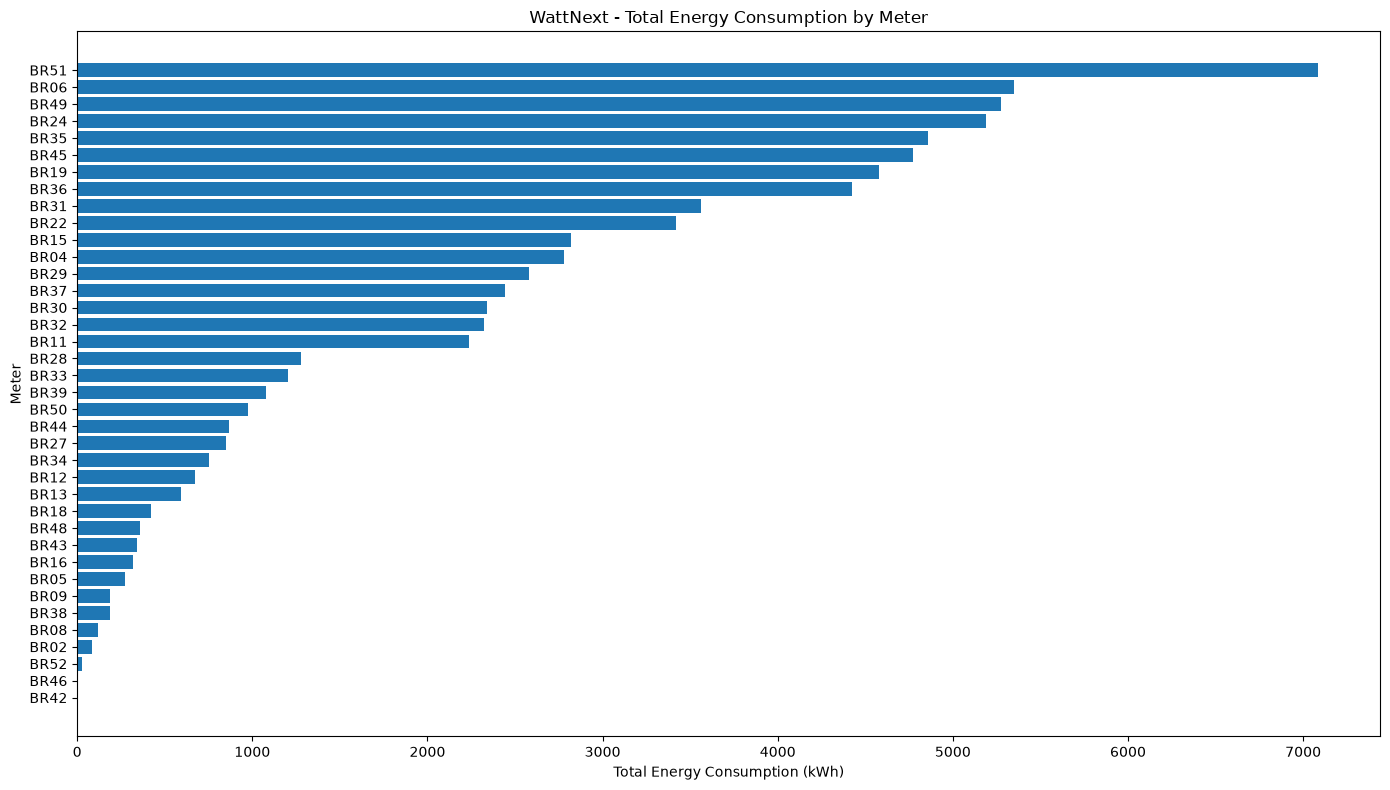

In [32]:
# ==========================================
# WATTNEXT - TOTAL ENERGY BY METER
# ==========================================

plt.figure(figsize=(14, 8))

plt.barh(
    meter_energy_summary.index,
    meter_energy_summary["total_energy"]
)

plt.xlabel("Total Energy Consumption (kWh)")
plt.ylabel("Meter")
plt.title("WattNext - Total Energy Consumption by Meter")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

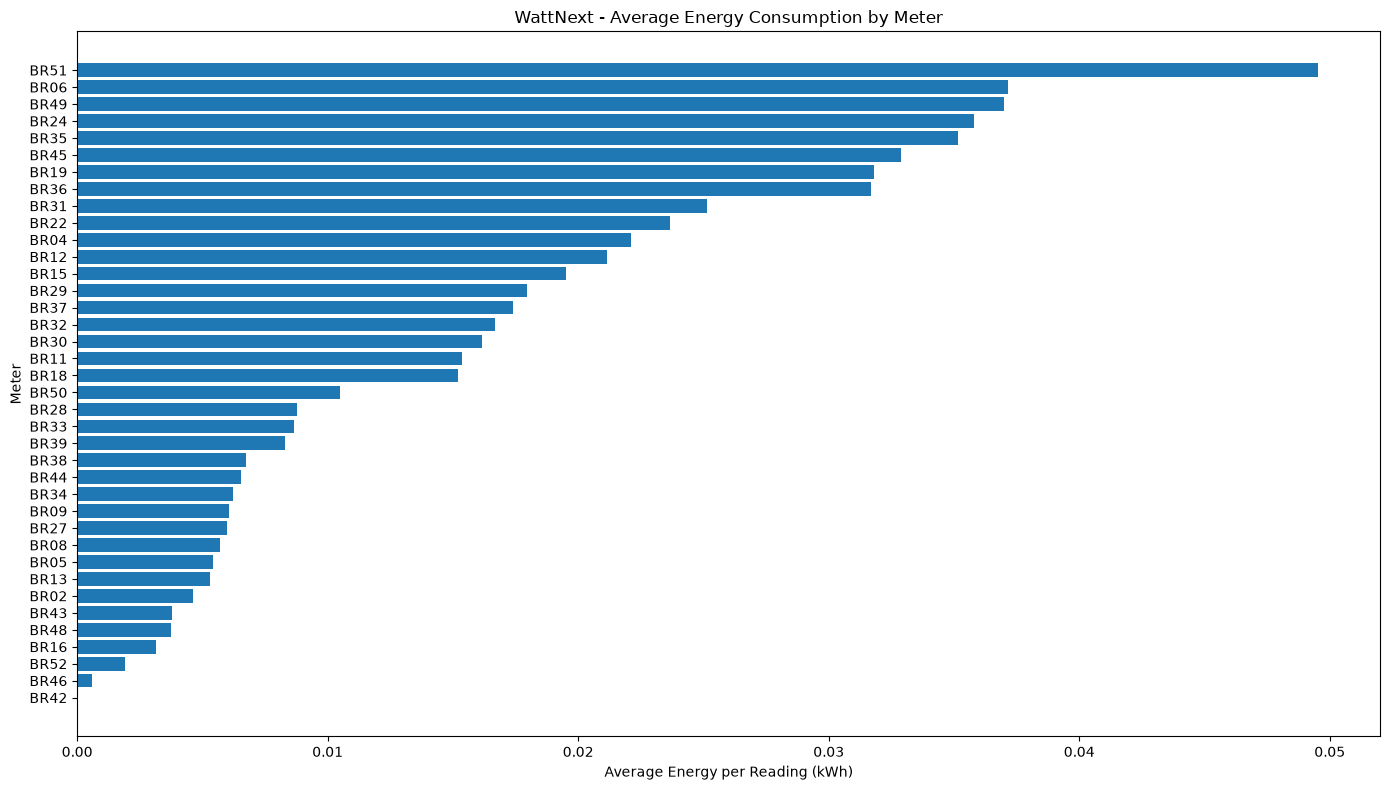

In [33]:
plt.figure(figsize=(14, 8))

average_energy_sorted = meter_energy_summary.sort_values(
    "average_energy",
    ascending=False
)

plt.barh(
    average_energy_sorted.index,
    average_energy_sorted["average_energy"]
)

plt.xlabel("Average Energy per Reading (kWh)")
plt.ylabel("Meter")
plt.title("WattNext - Average Energy Consumption by Meter")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
df["timestamp"] = pd.to_datetime(df["x_Timestamp"])

df["hour"] = df["timestamp"].dt.hour

hourly_energy = df.groupby("hour")["t_kWh"].mean()

print(hourly_energy)

hour
0     0.022158
1     0.021029
2     0.020095
3     0.019123
4     0.017921
5     0.016553
6     0.014061
7     0.015485
8     0.019131
9     0.019919
10    0.019931
11    0.019621
12    0.018310
13    0.019102
14    0.020609
15    0.019536
16    0.018362
17    0.017520
18    0.017780
19    0.019601
20    0.021598
21    0.022192
22    0.022585
23    0.023509
Name: t_kWh, dtype: float64


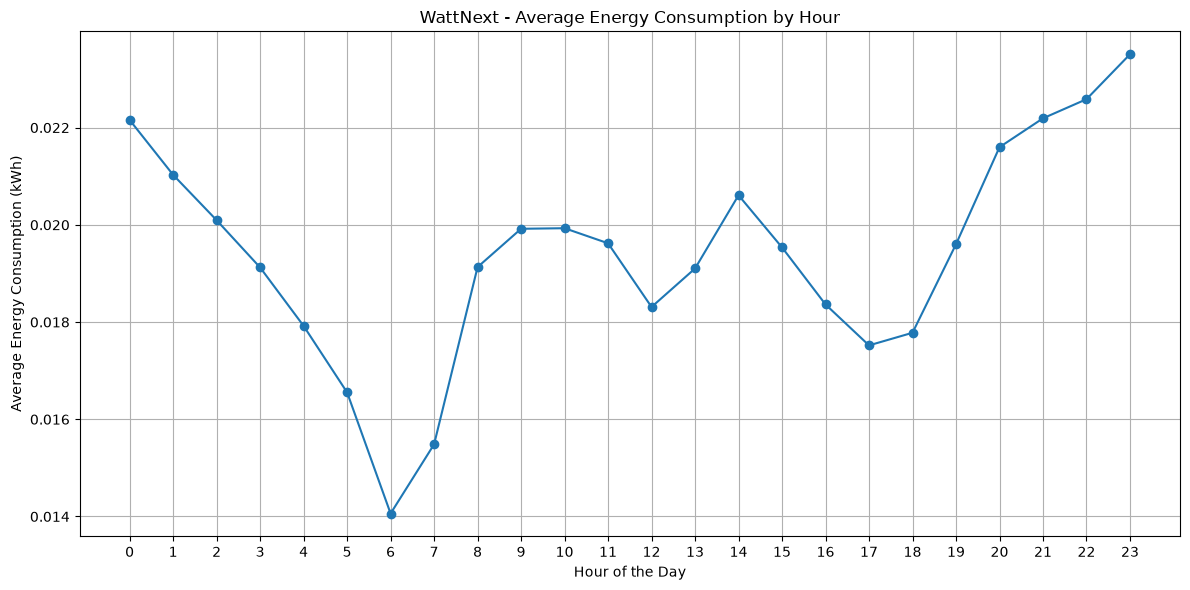

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_energy.index,
    hourly_energy.values,
    marker="o"
)

plt.xlabel("Hour of the Day")
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("WattNext - Average Energy Consumption by Hour")

plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

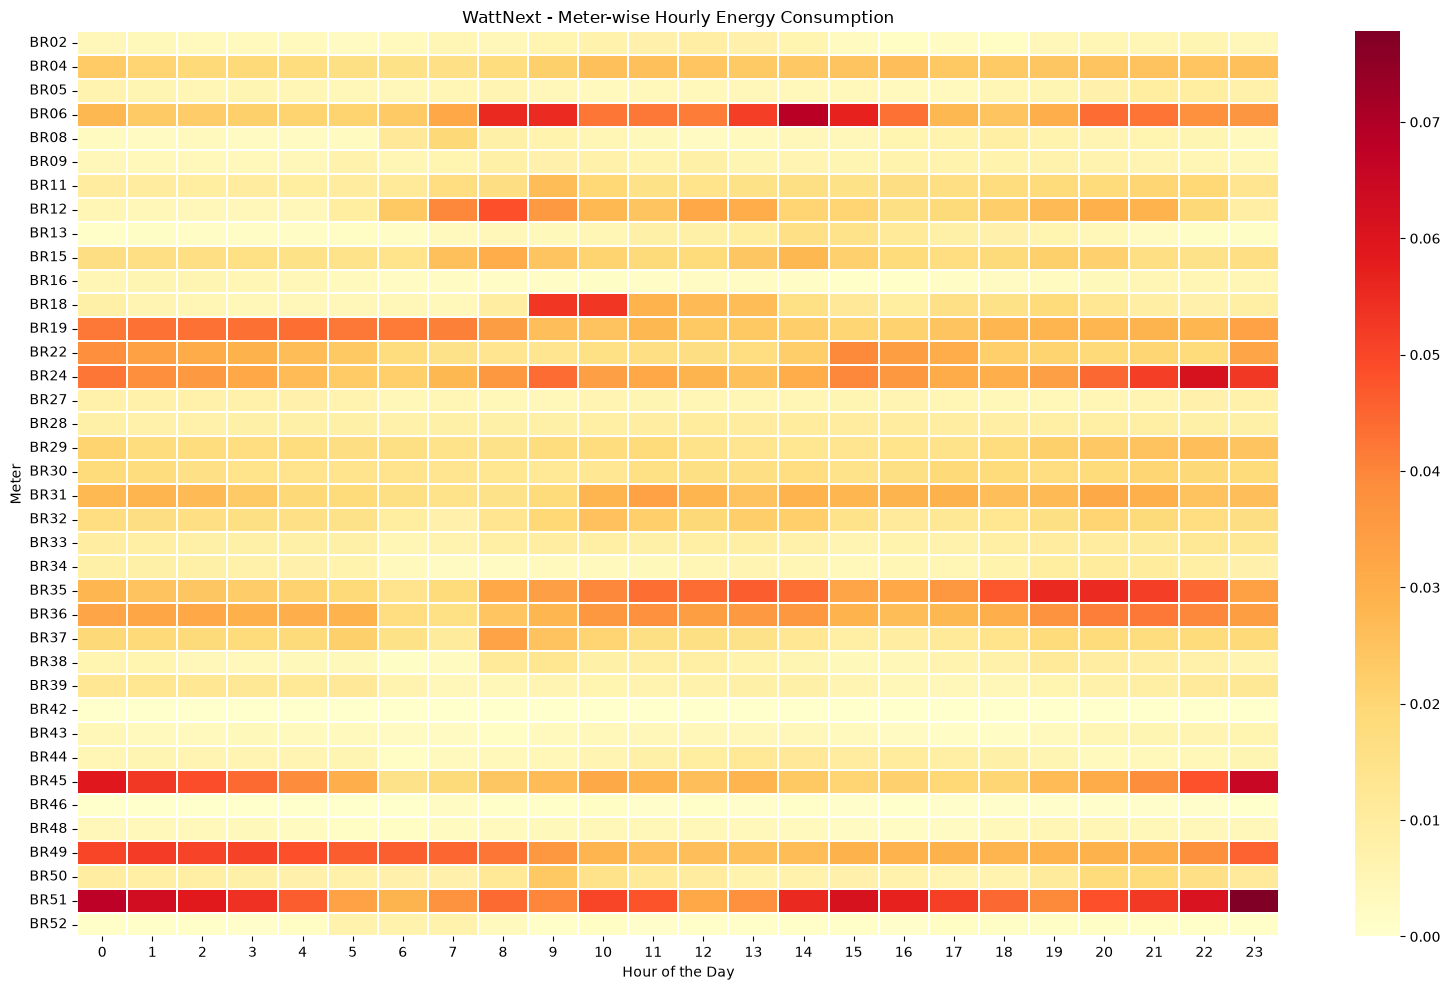

In [37]:
# Calculate average hourly consumption for each meter
import seaborn as sns
meter_hourly = df.groupby(
    ["meter", "hour"]
)["t_kWh"].mean().unstack()

# Create the heatmap
plt.figure(figsize=(16, 10))

sns.heatmap(
    meter_hourly,
    cmap="YlOrRd",
    linewidths=0.1
)

plt.xlabel("Hour of the Day")
plt.ylabel("Meter")
plt.title("WattNext - Meter-wise Hourly Energy Consumption")

plt.tight_layout()
plt.show()

In [39]:
# Make sure all 24 hours exist as columns
import numpy as np
meter_hourly = meter_hourly.reindex(
    columns=range(24),
    fill_value=0
)

# Calculate each meter's average hourly consumption
meter_average = meter_hourly.mean(axis=1)

# Avoid division by zero
meter_average = meter_average.replace(0, np.nan)

# Normalize each meter's hourly pattern
meter_profiles = meter_hourly.div(
    meter_average,
    axis=0
).fillna(0)

print("Original shape:", meter_hourly.shape)
print("Normalized shape:", meter_profiles.shape)

display(meter_profiles.head())

Original shape: (38, 24)
Normalized shape: (38, 24)


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
meter,,,,,,,,,,,,,,,,,,,,,
BR02,0.917649,0.806913,0.774603,0.749474,0.695072,0.529657,0.747264,1.057106,0.962938,1.315583,...,1.366395,0.606427,0.430795,0.509775,0.424444,0.929800,1.063733,1.119792,1.242127,0.972327
BR04,1.035075,0.925405,0.856378,0.854771,0.802096,0.739469,0.698611,0.705547,0.807417,0.979420,...,1.065836,1.116265,1.180896,1.085557,1.058821,1.090722,1.122001,1.132237,1.110529,1.157167
BR05,1.229853,1.054096,0.997787,1.020045,0.983333,0.876477,0.800570,0.929417,1.101982,0.804384,...,0.745325,0.780884,0.631908,0.630755,0.907071,1.059594,1.395323,1.835601,1.799953,1.431503
BR06,0.750499,0.629569,0.610431,0.584091,0.558943,0.559957,0.629219,0.850659,1.489081,1.485458,...,1.836613,1.531698,1.154103,0.750176,0.664472,0.807333,1.179731,1.147057,1.017211,0.987879
BR08,0.485336,0.476156,0.539617,0.457797,0.453606,0.524051,2.063677,3.387576,1.426274,1.211345,...,0.755345,0.765123,1.077439,1.192786,1.574749,1.215935,1.057881,1.079434,1.004399,0.622635


In [40]:
# Check the normalized data
print("Number of meters:", meter_profiles.shape[0])
print("Number of features:", meter_profiles.shape[1])

print("\nMissing values:")
print(meter_profiles.isnull().sum().sum())

print("\nData preview:")
display(meter_profiles.head())

Number of meters: 38
Number of features: 24

Missing values:
0

Data preview:


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
meter,,,,,,,,,,,,,,,,,,,,,
BR02,0.917649,0.806913,0.774603,0.749474,0.695072,0.529657,0.747264,1.057106,0.962938,1.315583,...,1.366395,0.606427,0.430795,0.509775,0.424444,0.929800,1.063733,1.119792,1.242127,0.972327
BR04,1.035075,0.925405,0.856378,0.854771,0.802096,0.739469,0.698611,0.705547,0.807417,0.979420,...,1.065836,1.116265,1.180896,1.085557,1.058821,1.090722,1.122001,1.132237,1.110529,1.157167
BR05,1.229853,1.054096,0.997787,1.020045,0.983333,0.876477,0.800570,0.929417,1.101982,0.804384,...,0.745325,0.780884,0.631908,0.630755,0.907071,1.059594,1.395323,1.835601,1.799953,1.431503
BR06,0.750499,0.629569,0.610431,0.584091,0.558943,0.559957,0.629219,0.850659,1.489081,1.485458,...,1.836613,1.531698,1.154103,0.750176,0.664472,0.807333,1.179731,1.147057,1.017211,0.987879
BR08,0.485336,0.476156,0.539617,0.457797,0.453606,0.524051,2.063677,3.387576,1.426274,1.211345,...,0.755345,0.765123,1.077439,1.192786,1.574749,1.215935,1.057881,1.079434,1.004399,0.622635


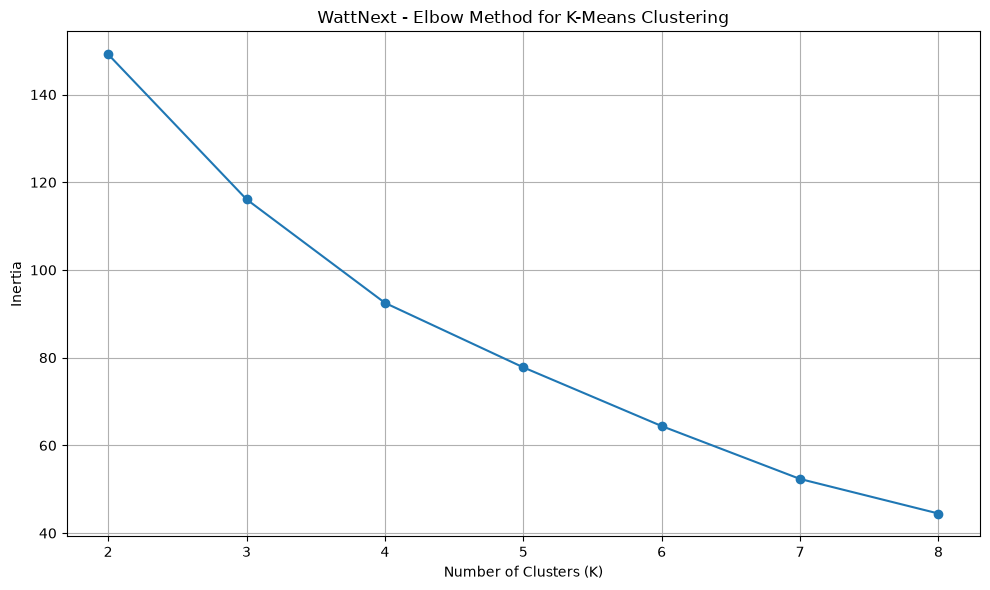

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(meter_profiles)
    inertias.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("WattNext - Elbow Method for K-Means Clustering")

plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()


K = 2, Silhouette Score = 0.2265
K = 3, Silhouette Score = 0.2209
K = 4, Silhouette Score = 0.1973
K = 5, Silhouette Score = 0.1929
K = 6, Silhouette Score = 0.1768
K = 7, Silhouette Score = 0.1903
K = 8, Silhouette Score = 0.1765


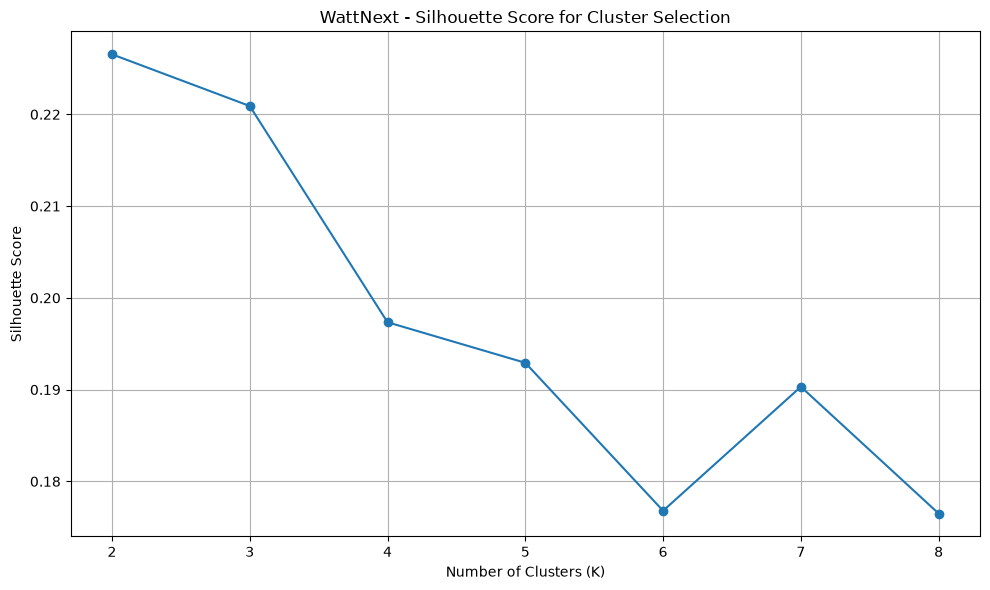

In [42]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(meter_profiles)

    score = silhouette_score(
        meter_profiles,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("WattNext - Silhouette Score for Cluster Selection")

plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
from sklearn.cluster import KMeans

# Create the K-Means model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Train the model and generate cluster labels
cluster_labels = kmeans.fit_predict(meter_profiles)

# Create a results table
cluster_results = meter_profiles.copy()

cluster_results["cluster"] = cluster_labels

print("Clustering completed!")

print("\nMeters in each cluster:")
print(cluster_results["cluster"].value_counts().sort_index())

display(cluster_results.head())

Clustering completed!

Meters in each cluster:
cluster
0    15
1    23
Name: count, dtype: int64


hour,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,cluster
meter,,,,,,,,,,,,,,,,,,,,,
BR02,0.917649,0.806913,0.774603,0.749474,0.695072,0.529657,0.747264,1.057106,0.962938,1.315583,...,0.606427,0.430795,0.509775,0.424444,0.929800,1.063733,1.119792,1.242127,0.972327,0
BR04,1.035075,0.925405,0.856378,0.854771,0.802096,0.739469,0.698611,0.705547,0.807417,0.979420,...,1.116265,1.180896,1.085557,1.058821,1.090722,1.122001,1.132237,1.110529,1.157167,1
BR05,1.229853,1.054096,0.997787,1.020045,0.983333,0.876477,0.800570,0.929417,1.101982,0.804384,...,0.780884,0.631908,0.630755,0.907071,1.059594,1.395323,1.835601,1.799953,1.431503,1
BR06,0.750499,0.629569,0.610431,0.584091,0.558943,0.559957,0.629219,0.850659,1.489081,1.485458,...,1.531698,1.154103,0.750176,0.664472,0.807333,1.179731,1.147057,1.017211,0.987879,0
BR08,0.485336,0.476156,0.539617,0.457797,0.453606,0.524051,2.063677,3.387576,1.426274,1.211345,...,0.765123,1.077439,1.192786,1.574749,1.215935,1.057881,1.079434,1.004399,0.622635,0


In [44]:
# Display meters belonging to each cluster

for cluster_number in sorted(cluster_results["cluster"].unique()):
    meters = cluster_results[
        cluster_results["cluster"] == cluster_number
    ].index.tolist()

    print(f"\nCluster {cluster_number}")
    print("Number of meters:", len(meters))
    print("Meters:", meters)


Cluster 0
Number of meters: 15
Meters: ['BR02', 'BR06', 'BR08', 'BR09', 'BR11', 'BR12', 'BR13', 'BR15', 'BR18', 'BR35', 'BR38', 'BR44', 'BR46', 'BR50', 'BR52']

Cluster 1
Number of meters: 23
Meters: ['BR04', 'BR05', 'BR16', 'BR19', 'BR22', 'BR24', 'BR27', 'BR28', 'BR29', 'BR30', 'BR31', 'BR32', 'BR33', 'BR34', 'BR36', 'BR37', 'BR39', 'BR42', 'BR43', 'BR45', 'BR48', 'BR49', 'BR51']


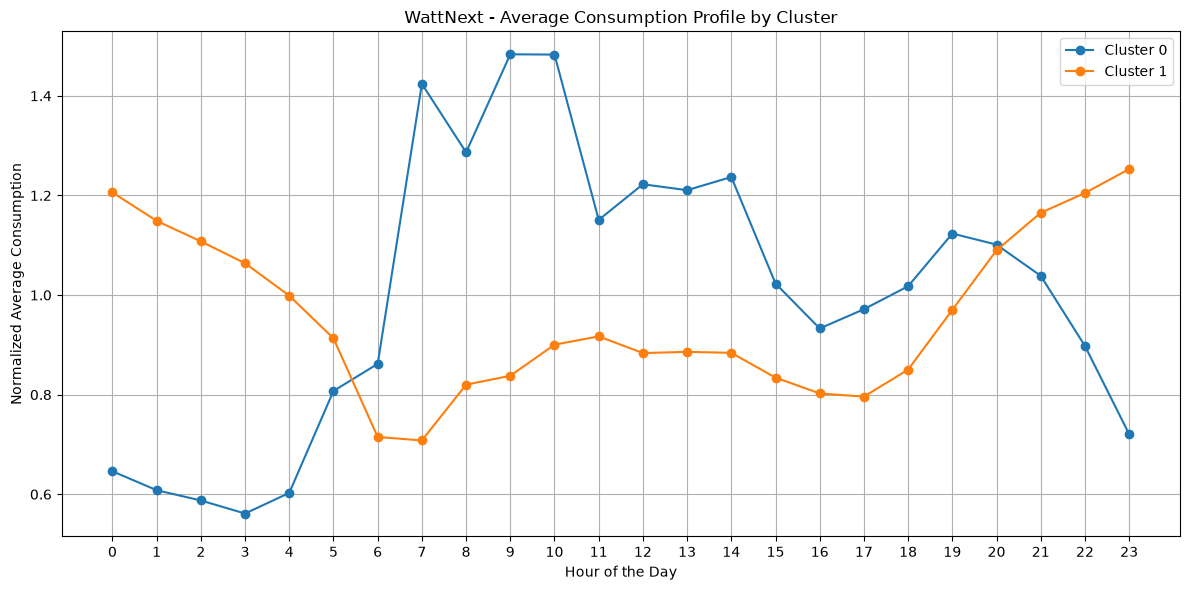

In [45]:
# Calculate the average hourly profile of each cluster
cluster_profiles = cluster_results.groupby("cluster")[
    list(range(24))
].mean()

# Plot cluster profiles
plt.figure(figsize=(12, 6))

for cluster_number in cluster_profiles.index:
    plt.plot(
        range(24),
        cluster_profiles.loc[cluster_number],
        marker="o",
        label=f"Cluster {cluster_number}"
    )

plt.xlabel("Hour of the Day")
plt.ylabel("Normalized Average Consumption")
plt.title("WattNext - Average Consumption Profile by Cluster")

plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# Add cluster labels to the original dataset
df_with_clusters = df.merge(
    cluster_results[["cluster"]],
    left_on="meter",
    right_index=True,
    how="left"
)

# Compare actual consumption by cluster
cluster_summary = df_with_clusters.groupby("cluster").agg(
    total_energy=("t_kWh", "sum"),
    average_energy=("t_kWh", "mean"),
    total_readings=("t_kWh", "count"),
    number_of_meters=("meter", "nunique")
)

print(cluster_summary)

         total_energy  average_energy  total_readings  number_of_meters
cluster                                                                
0           19414.132        0.017771         1092480                15
1           57217.438        0.020031         2856480                23


In [47]:
# Save meter-level clustering results
cluster_results.to_csv(
    "../data/processed/meter_clusters.csv"
)

print("Cluster results saved successfully!")

Cluster results saved successfully!


In [48]:
import os

file_path = "../data/processed/meter_clusters.csv"

print("File exists:", os.path.exists(file_path))

File exists: True


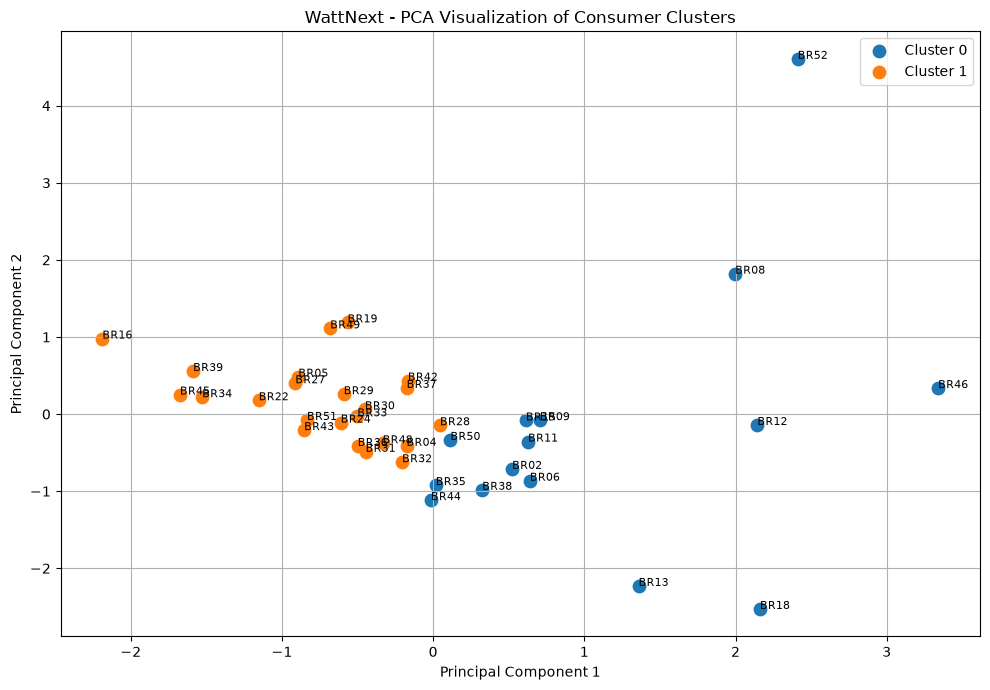

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce 24 hourly features to 2 dimensions
pca = PCA(n_components=2)

pca_data = pca.fit_transform(meter_profiles)

# Create a DataFrame for visualization
pca_results = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"],
    index=meter_profiles.index
)

# Add cluster labels
pca_results["cluster"] = cluster_labels

# Plot the clusters
plt.figure(figsize=(10, 7))

for cluster_number in sorted(pca_results["cluster"].unique()):
    cluster_data = pca_results[
        pca_results["cluster"] == cluster_number
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_number}",
        s=80
    )

    # Add meter names
    for meter in cluster_data.index:
        plt.annotate(
            meter,
            (
                cluster_data.loc[meter, "PC1"],
                cluster_data.loc[meter, "PC2"]
            ),
            fontsize=8
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("WattNext - PCA Visualization of Consumer Clusters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
# Calculate explained variance
explained_variance = pca.explained_variance_ratio_

print("PC1 explained variance:",
      round(explained_variance[0] * 100, 2), "%")

print("PC2 explained variance:",
      round(explained_variance[1] * 100, 2), "%")

print("Total explained variance:",
      round(explained_variance.sum() * 100, 2), "%")

PC1 explained variance: 29.29 %
PC2 explained variance: 25.47 %
Total explained variance: 54.77 %


In [51]:
from sklearn.metrics import silhouette_samples

# Calculate silhouette score for every meter
individual_scores = silhouette_samples(
    meter_profiles,
    cluster_labels
)

# Create a table
silhouette_results = pd.DataFrame({
    "meter": meter_profiles.index,
    "cluster": cluster_labels,
    "silhouette_score": individual_scores
})

# Sort from weakest to strongest assignment
silhouette_results = silhouette_results.sort_values(
    "silhouette_score"
)

display(silhouette_results)

,meter,cluster,silhouette_score
23,BR35,0,-0.255494
35,BR50,0,-0.226056
30,BR44,0,-0.195804
9,BR15,0,-0.190105
5,BR09,0,-0.171315
6,BR11,0,-0.157316
0,BR02,0,-0.152721
26,BR38,0,-0.133906
3,BR06,0,-0.090006
37,BR52,0,-0.017286


In [52]:
# Train a K-Means model with 3 clusters
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_3 = kmeans_3.fit_predict(meter_profiles)

# Calculate silhouette score
score_3 = silhouette_score(
    meter_profiles,
    labels_3
)

print("K = 3 Silhouette Score:", round(score_3, 4))

# Display number of meters per cluster
print("\nMeters in each cluster:")
print(pd.Series(labels_3).value_counts().sort_index())

K = 3 Silhouette Score: 0.2209

Meters in each cluster:
0    11
1    24
2     3
Name: count, dtype: int64


In [53]:
# Create a table for K = 3 results
cluster_3_results = pd.DataFrame({
    "meter": meter_profiles.index,
    "cluster": labels_3
})

# Display meters in each cluster
for cluster_number in sorted(cluster_3_results["cluster"].unique()):
    meters = cluster_3_results[
        cluster_3_results["cluster"] == cluster_number
    ]["meter"].tolist()

    print(f"\nCluster {cluster_number}")
    print("Number of meters:", len(meters))
    print("Meters:", meters)


Cluster 0
Number of meters: 11
Meters: ['BR02', 'BR06', 'BR09', 'BR11', 'BR12', 'BR13', 'BR15', 'BR18', 'BR35', 'BR38', 'BR44']

Cluster 1
Number of meters: 24
Meters: ['BR04', 'BR05', 'BR16', 'BR19', 'BR22', 'BR24', 'BR27', 'BR28', 'BR29', 'BR30', 'BR31', 'BR32', 'BR33', 'BR34', 'BR36', 'BR37', 'BR39', 'BR42', 'BR43', 'BR45', 'BR48', 'BR49', 'BR50', 'BR51']

Cluster 2
Number of meters: 3
Meters: ['BR08', 'BR46', 'BR52']


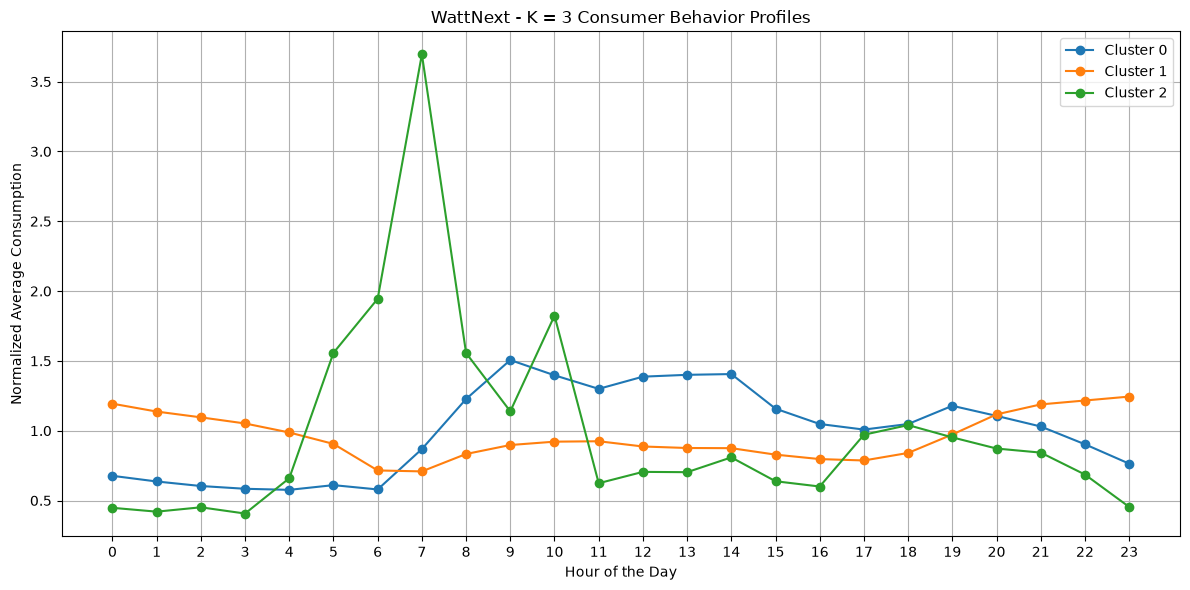

In [54]:
# Create a results table for K = 3
cluster_3_profiles_data = meter_profiles.copy()
cluster_3_profiles_data["cluster"] = labels_3

# Calculate average hourly profile for each cluster
cluster_3_profiles = cluster_3_profiles_data.groupby("cluster")[
    list(range(24))
].mean()

# Plot the profiles
plt.figure(figsize=(12, 6))

for cluster_number in cluster_3_profiles.index:
    plt.plot(
        range(24),
        cluster_3_profiles.loc[cluster_number],
        marker="o",
        label=f"Cluster {cluster_number}"
    )

plt.xlabel("Hour of the Day")
plt.ylabel("Normalized Average Consumption")
plt.title("WattNext - K = 3 Consumer Behavior Profiles")

plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
# Inspect the three meters in K = 3, Cluster 2

cluster_2_meters = cluster_3_results[
    cluster_3_results["cluster"] == 2
]["meter"].tolist()

print("Cluster 2 meters:", cluster_2_meters)

# Display their normalized hourly profiles
display(
    meter_profiles.loc[cluster_2_meters]
)

Cluster 2 meters: ['BR08', 'BR46', 'BR52']


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
meter,,,,,,,,,,,,,,,,,,,,,
BR08,0.485336,0.476156,0.539617,0.457797,0.453606,0.524051,2.063677,3.387576,1.426274,1.211345,...,0.755345,0.765123,1.077439,1.192786,1.574749,1.215935,1.057881,1.079434,1.004399,0.622635
BR46,0.469308,0.444822,0.428499,0.452984,0.461146,0.485632,0.028567,3.909539,1.648699,1.640537,...,1.216120,0.648869,0.440741,0.681517,0.783540,0.914130,0.861078,0.848835,0.595817,0.395851
BR52,0.388384,0.339530,0.385941,0.309404,1.064188,3.663184,3.742163,3.790202,1.593432,0.564256,...,0.455150,0.499932,0.282535,1.038947,0.762112,0.726286,0.697788,0.600896,0.457593,0.343602


In [56]:
# Investigate the three unusual meters

unusual_meters = ["BR08", "BR46", "BR52"]

unusual_summary = df[
    df["meter"].isin(unusual_meters)
].groupby("meter").agg(
    total_readings=("t_kWh", "count"),
    average_energy=("t_kWh", "mean"),
    total_energy=("t_kWh", "sum"),
    zero_energy_percentage=(
        "t_kWh",
        lambda x: (x == 0).mean() * 100
    )
)

display(unusual_summary)

,total_readings,average_energy,total_energy,zero_energy_percentage
meter,,,,
BR08,21120,0.005694,120.263,4.015152
BR46,10080,0.000583,5.881,73.849206
BR52,15360,0.001919,29.476,55.260417


In [57]:
# Create a data reliability summary for every meter

reliability_summary = df.groupby("meter").agg(
    total_readings=("t_kWh", "count"),
    average_energy=("t_kWh", "mean"),
    zero_energy_percentage=(
        "t_kWh",
        lambda x: (x == 0).mean() * 100
    ),
    average_voltage=("z_Avg Voltage (Volt)", "mean"),
    average_current=("z_Avg Current (Amp)", "mean"),
    average_frequency=("y_Freq (Hz)", "mean")
)

# Sort by zero-energy percentage
reliability_summary = reliability_summary.sort_values(
    "zero_energy_percentage",
    ascending=False
)

display(reliability_summary)

,total_readings,average_energy,zero_energy_percentage,average_voltage,average_current,average_frequency
meter,,,,,,
BR42,480,0.000000,100.000000,212.627708,0.000125,43.746167
BR46,10080,0.000583,73.849206,216.447904,0.066627,42.979709
BR38,27360,0.006748,60.442251,206.057274,0.615452,42.013814
BR52,15360,0.001919,55.260417,248.963449,0.194777,49.116995
BR44,132960,0.006535,54.958634,207.441197,0.564040,42.966875
BR32,139200,0.016671,36.003592,178.883840,1.823960,40.216824
BR43,90720,0.003767,33.988095,208.526933,0.323834,41.404771
BR48,96480,0.003728,32.826493,200.832135,0.359309,43.562899
BR13,111360,0.005320,31.672055,234.743367,0.499051,48.444677


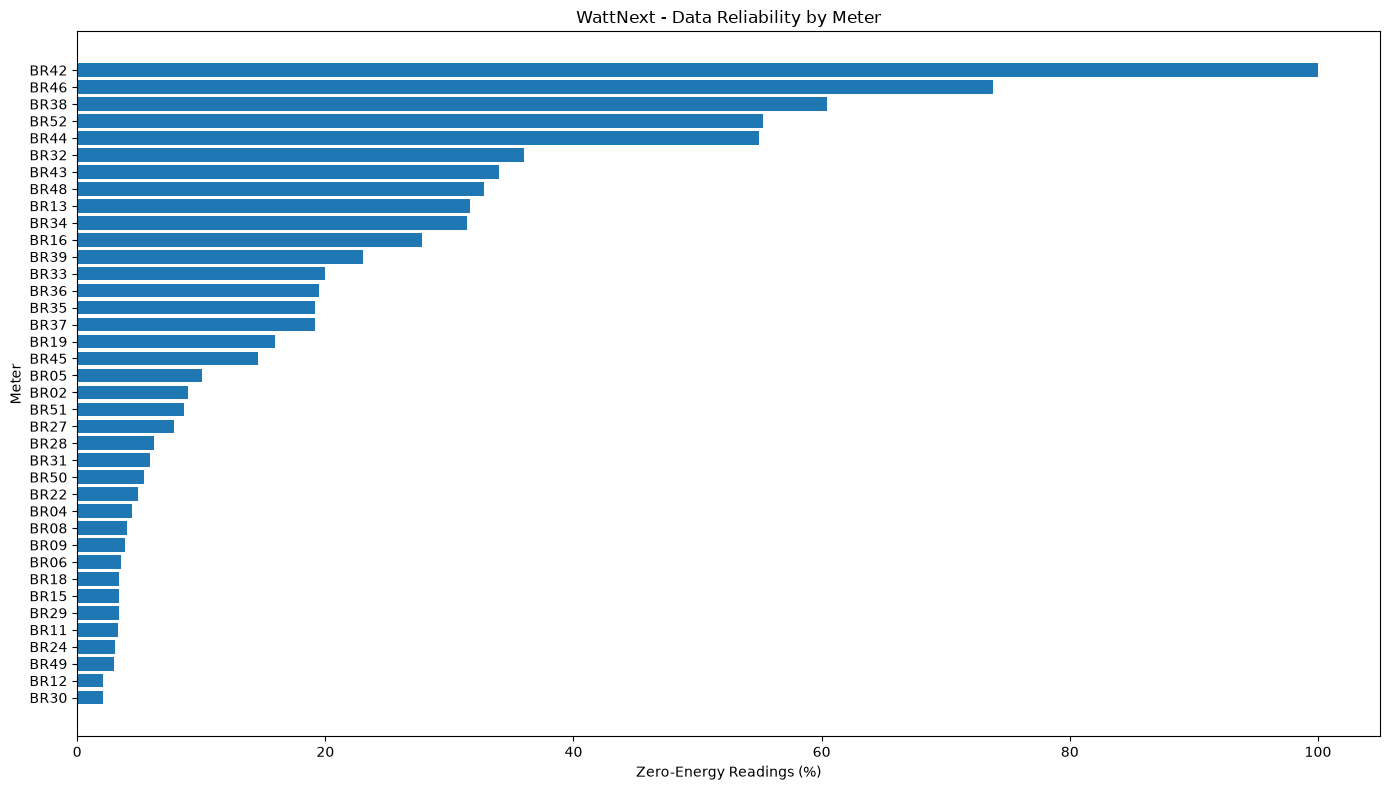

In [58]:
# Plot zero-energy percentage for each meter

plt.figure(figsize=(14, 8))

reliability_plot = reliability_summary.sort_values(
    "zero_energy_percentage",
    ascending=True
)

plt.barh(
    reliability_plot.index,
    reliability_plot["zero_energy_percentage"]
)

plt.xlabel("Zero-Energy Readings (%)")
plt.ylabel("Meter")
plt.title("WattNext - Data Reliability by Meter")

plt.tight_layout()
plt.show()